<a href="https://colab.research.google.com/github/sys8815701-creator/AI_26/blob/main/03_01_K_%EC%B5%9C%EA%B7%BC%EC%A0%91%EC%9D%B4%EC%9B%83%ED%9A%8C%EA%B7%80%EC%95%8C%EA%B3%A0%EB%A6%AC%EC%A6%98.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# 이번에는 농어철에 농어 주문이 크게 늘어서, MBC 마켓에서 업계 최초로 농어를 무게 단위로 판매하고자 한다.
# 무게 단위로 판매하면, 가격 측정도 원활하고 고객도 합리적으로 판단할 수 있다.
# 다만, 공급처에서 생선 무게를 잘못 측정하는 실수도 발생할 수 있다. → 농어의 무게를 다시 측정해야 한다.
# 다른 데이터는 정상 범위가 있으니 예측할 수 있을까?
# 이렇게 두 변수 사이의 상관관계를 분석하고 예측하는 방법을 회귀라고 한다. → 샘플 데이터가 필요하다.
# 외부에서 58개의 샘플을 받아서 처리해보자.
# 지도 학습은 크게 2개로 나뉜다.
# 분류 (2진 분류) : from sklearn.neighbors import KNeighborsClassifier
# 회귀 (임의의 특정 숫자로 예측) : from sklearn.neighbors import KNeighborsRegressor

In [6]:
# !sudo : 가상머신 명령어 처리 (관리자 권한)
!sudo apt-get install -y fonts-nanum # 리눅스 명령어로, 코랩의 가상머신에 나눔 폰트를 설치하고 적용하는 명령어 → 차트에 한글 처리용
!sudo fc-cache -fv
!rm ~/.cache/matplotlib -rf # 설치 후에 세션을 재시작한다.

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
fonts-nanum is already the newest version (20200506-1).
0 upgraded, 0 newly installed, 0 to remove and 2 not upgraded.
/usr/share/fonts: caching, new cache contents: 0 fonts, 1 dirs
/usr/share/fonts/truetype: caching, new cache contents: 0 fonts, 3 dirs
/usr/share/fonts/truetype/humor-sans: caching, new cache contents: 1 fonts, 0 dirs
/usr/share/fonts/truetype/liberation: caching, new cache contents: 16 fonts, 0 dirs
/usr/share/fonts/truetype/nanum: caching, new cache contents: 12 fonts, 0 dirs
/usr/local/share/fonts: caching, new cache contents: 0 fonts, 0 dirs
/root/.local/share/fonts: skipping, no such directory
/root/.fonts: skipping, no such directory
/usr/share/fonts/truetype: skipping, looped directory detected
/usr/share/fonts/truetype/humor-sans: skipping, looped directory detected
/usr/share/fonts/truetype/liberation: skipping, looped directory detected
/usr/share/fonts/truetype/n

In [1]:
# 농어의 샘플 자료 58개
import numpy as np

# 농어의 길이 배열리스트
perch_length = np.array([8.4, 13.7, 15.0, 16.2, 17.4, 18.0, 18.7, 19.0, 19.6, 20.0, 21.0,
       21.0, 21.0, 21.3, 22.0, 22.0, 22.0, 22.0, 22.0, 22.5, 22.5, 22.7,
       23.0, 23.5, 24.0, 24.0, 24.6, 25.0, 25.6, 26.5, 27.3, 27.5, 27.5,
       27.5, 28.0, 28.7, 30.0, 32.8, 34.5, 35.0, 36.5, 36.0, 37.0, 37.0,
       39.0, 39.0, 39.0, 40.0, 40.0, 40.0, 40.0, 42.0, 43.0, 43.0, 43.5,
       44.0])

# 농어의 무게 배열리스트
perch_weight = np.array([5.9, 32.0, 40.0, 51.5, 70.0, 100.0, 78.0, 80.0, 85.0, 85.0, 110.0,
       115.0, 125.0, 130.0, 120.0, 120.0, 130.0, 135.0, 110.0, 130.0,
       150.0, 145.0, 150.0, 170.0, 225.0, 145.0, 188.0, 180.0, 197.0,
       218.0, 300.0, 260.0, 265.0, 250.0, 250.0, 300.0, 320.0, 514.0,
       556.0, 840.0, 685.0, 700.0, 700.0, 690.0, 900.0, 650.0, 820.0,
       850.0, 900.0, 1015.0, 820.0, 1100.0, 1000.0, 1100.0, 1000.0,
       1000.0])

기초 자료


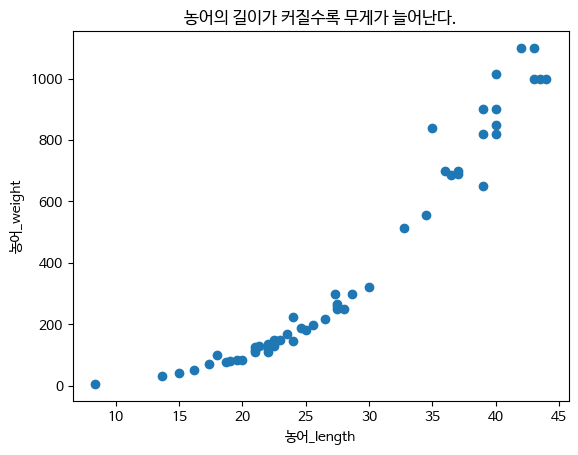

In [2]:
import matplotlib.pyplot as plt
plt.rc('font', family = 'NanumBarunGothic') # 한글 처리

plt.scatter(perch_length, perch_weight) # 농어의 길이(x축), 농어의 무게 (y축)
plt.xlabel('농어_length')
plt.ylabel('농어_weight')
print('기초 자료')
plt.title('농어의 길이가 커질수록 무게가 늘어난다.')
plt.show()

# 결과 : 산점도를 그리고 나니 길이가 길어짐에 따라 무게도 늘어난다.
# 이 데이터를 토대로 훈련(.fit)과 테스트(.score)를 진행해보자.

In [ ]:
# K - 최근접 이웃 알고리즘에서의 회귀 : KNeighborsRegressor

# 예측하려는 샘플에 가장 가까운 샘플 k개를 선택한다. → 샘플들의 클래스를 확인하여 다수 클래스를 새로운 샘플의 클래스로 예측한다.
# 'k = 3'이라고 가정하면 2개의 다수가 있기 때문에 사각형으로 판단한다.
# 회귀는 샘플에서 가장 가까운 샘플 k개를 선택한다.
# 타깃값 '100, 80, 80'을 더해 3으로 나눈 평균이 타깃 값으로 사용된다.

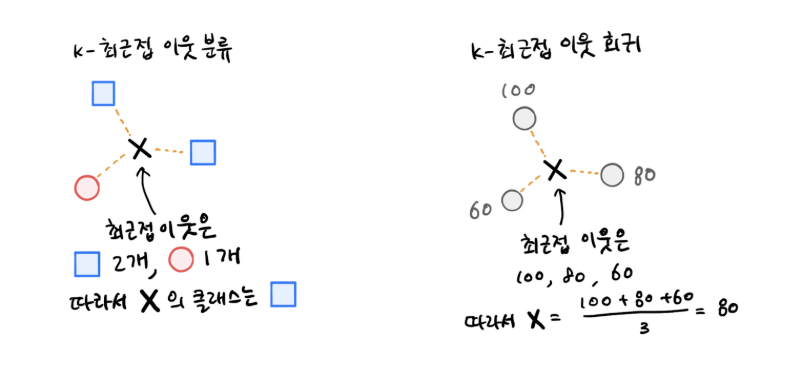

In [3]:
# 사이킷런에서 제공하는 훈련 세트, 테스트 세트를 생성한다.
from sklearn.model_selection import train_test_split

train_input, test_input, train_target, test_target = train_test_split(
    perch_length, perch_weight, random_state = 42) # 1줄 작성을 권장한다.
#      input         target

# 정답 파일이 무게 확률이기 때문에, 'stratify(분류용)' 사용하지 않는다.

# 사이킷런의 'train_test_split' 함수를 활용하여 훈련 세트와 테스트 세트로 나눈다.
# random_state = 42 : 서로 다른 테스트를 위해 시드 값을 제공한다.

# 사이킷런에 사용할 훈련 세트는 2차원 배열을 사용한다.
# 'perch_length'가 1차원 배열이기 때문에, 이를 나눈 'train_input'과 'test_input' 또한 1차원 배열이다.
# 2차원 배열을 사용해야 하기 때문에 억지로 변환 한다. → 'reshape()' 매서드를 활용한다. ((4,) → (2, 2))

In [4]:
test_array = np.array([1, 2, 3, 4])
print(test_array.shape) # 현재 1차원 배열로 나오는 출력값을 억지로 2차원 배열로 처리해야 한다.

(4,)


In [5]:
# 2차원 배열로 변환한다.
test_array = test_array.reshape(2, 2) # 억지로 2차원 배열을 만드는 기법
print(test_array.shape)
# 전에는 2개의 특성으로 사용했었기 때문에 자연스럽게 열이 2개인 2차원 배열을 사용했었지만 이번에는 특성이 1개로, 수동으로 2차원 배열을 만들어야 한다. → '넘파이.reshape()'를 활용한다.
# '(4,) → (2, 2)' 크기로 바꿔준다.

(2, 2)


In [6]:
print(test_array)

[[1 2]
 [3 4]]


In [7]:
# 입력 데이터인 'train_input'과 'test_input'을 2차원 배열로 바꿔야 한다.
# 넘파이는 배열의 크기를 자동으로 지정하는 기능도 제공하기 때문에, (-1) 값을 넣으면 된다.
train_input = train_input.reshape(-1, 1) # -1로 지정하면 원소 개수로 모두 채우라는 의미이다.
                                         # 1은 두 번째 크기를 1로 모두 채우라는 의미이다.
test_input = test_input.reshape(-1, 1)
print(train_input.shape, test_input.shape) # -1을 사용하면 매번 원소의 크기를 외우지 않아도 된다.

(42, 1) (14, 1)


In [8]:
print(train_input)

[[19.6]
 [22. ]
 [18.7]
 [17.4]
 [36. ]
 [25. ]
 [40. ]
 [39. ]
 [43. ]
 [22. ]
 [20. ]
 [22. ]
 [24. ]
 [27.5]
 [43. ]
 [40. ]
 [24. ]
 [21. ]
 [27.5]
 [40. ]
 [32.8]
 [26.5]
 [36.5]
 [13.7]
 [22.7]
 [15. ]
 [37. ]
 [35. ]
 [28.7]
 [23.5]
 [39. ]
 [21. ]
 [23. ]
 [22. ]
 [44. ]
 [22.5]
 [19. ]
 [37. ]
 [22. ]
 [25.6]
 [42. ]
 [34.5]]


In [ ]:
# ----------------------------- 전처리 데이터 끝 -----------------------------

In [9]:
# 훈련을 시작한다.
from sklearn.neighbors import KNeighborsRegressor # 리그레스 : 회귀 알고리즘용 구현 클래스 <-> from sklearn.neighbors import KNeighborsClassifier (분류용)

knr = KNeighborsRegressor() # 회귀용 객체 생성
knr.fit(train_input, train_target) # 회귀용 훈련
#        농어의 길이  농어의 무게

KNeighborsRegressor()

In [11]:
knr.score(test_input, test_target)
#        농어 테스트 길이 / 테스트 무게
# 분류의 경우, 테스트 세트에 있는 샘플을 정확하게 분류한 개수의 비율(정확도)이 예측값이 된다.
# 회귀의 경우, 평가를 결정 계수라고 한다. (R^2)
# R^2 = 1 = ((타깃 - 예측)^2의 합) / ((타깃 - 평균)^2의 합)
# 타깃의 평균 정도를 예측하는 수준 : R^2가 0에 가까워지고, 예측이 타깃에 가까워지면 1에 가까운 값이다.
# 결과 : 99.28% (예측이 가능한 수준)

0.992809406101064

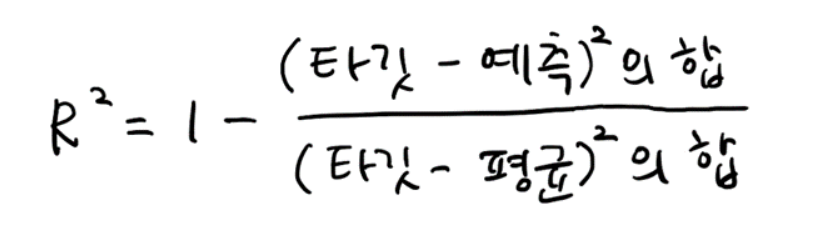

In [12]:
knr.predict([[15]]) # 알고 싶은 값 출력 → K에 가장 근접한 5개 데이터의 이웃에 대한 값 : 60g (99.28%)

array([60.])

In [14]:
# sklearn.metrics 패키지 아래 여러 가지 측정 도구를 제공한다.
# mean_absolute_error : 절대값 오차를 평균 내어 반환한다.
from sklearn.metrics import mean_absolute_error # 평균으로 절대값의 오차를 찾는 매서드

# 테스트 세트에 대한 예측(prediction)을 만든다.
test_prediction = knr.predict(test_input)

# 테스트 세트에 대한 평균 절댓값 오차를 계산한다.
mae = mean_absolute_error(test_target, test_prediction)

print(mae)
# 결과 : 19g 정도 타깃값과 다르다. (타깃과 예측한 값 사이의 차이)

19.157142857142862


In [15]:
print(knr.score(train_input, train_target)) # 훈련한 모델을 사용하여 훈련 세트 점수를 확인한다.
# 결과 : 약 96.98%

0.9698823289099254


In [16]:
knr.score(test_input, test_target)
# 결과 :약 99.28%

0.992809406101064

In [17]:
# 위의 결과를 보면, 훈련 세트로 훈련시키면 훈련 세트에 잘 맞는 모델이 만들어진다.
# 이 모델을 훈련 세트와 테스트 세트에서 평가하면 둘 중 어느 것이 더 높을까? → 훈련 세트가 보통 조금 더 높게 나온다.
# 과대 적합 : 훈련 세트에서 점수가 굉장히 좋았던 반면, 테스트 세트에서는 점수가 굉장히 나쁜 현상
# 과소 적합 : 훈련 세트보다 테스트 세트 점수가 더 높은 경우 혹은 두 점수가 모두 낮은 경우

# 사이킷런의 알고리즘 기본값을 3개로 조절해보자.

# 사이킷런의 'K - 최근접 이웃 알고리즘' 기본값은 5이지만 이를 3으로 변경한다.
knr.n_neighbors = 3
# 모델을 다시 훈련시킨다.
knr.fit(train_input, train_target) # 3개의 이웃용 생성 훈련
print(knr.score(train_input, train_target)) # 훈련 점수 보기 (98.04%)

0.9804899950518966


In [19]:
print(knr.score(test_input, test_target)) # 이웃 개수를 조정했기 때문에 과대, 과소 적합 문제가 해결되었다. (97.46%)

0.9746459963987609


In [20]:
knr.predict([[15]]) # 알고 싶은 값 출력 (15cm → 47.3333333g)
# 결과 : 5개의 이웃을 참고하는 것보다 3개를 참고하는 게 더 좋은 결과가 나온다.

array([47.33333333])

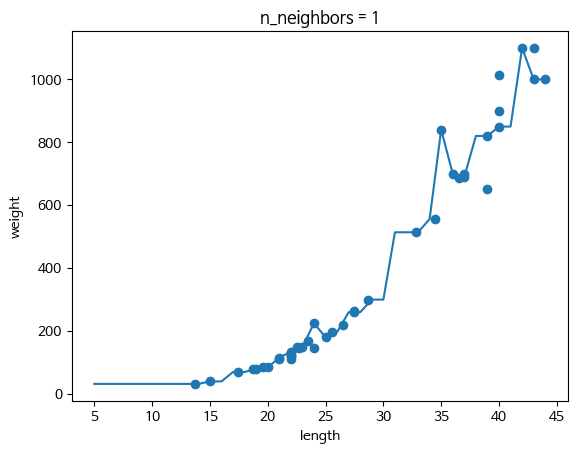

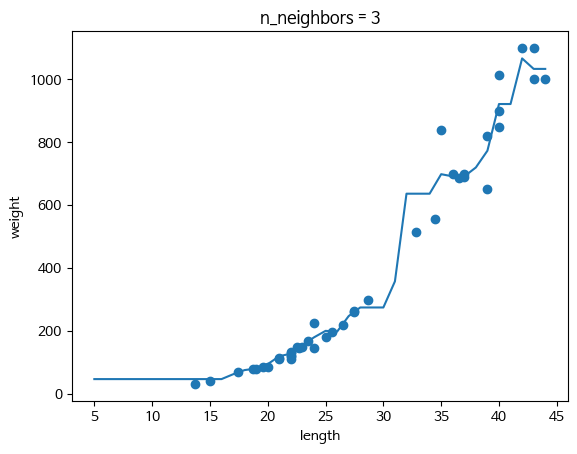

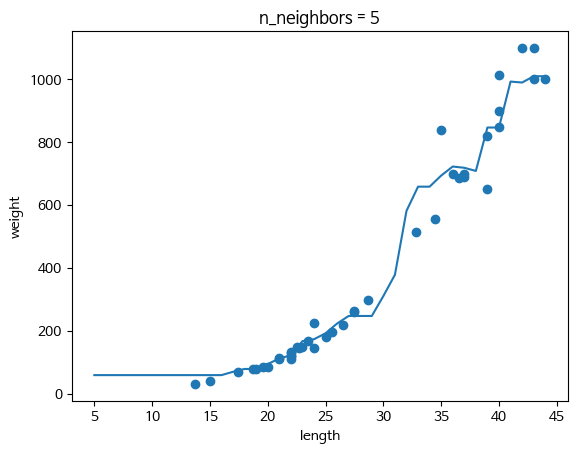

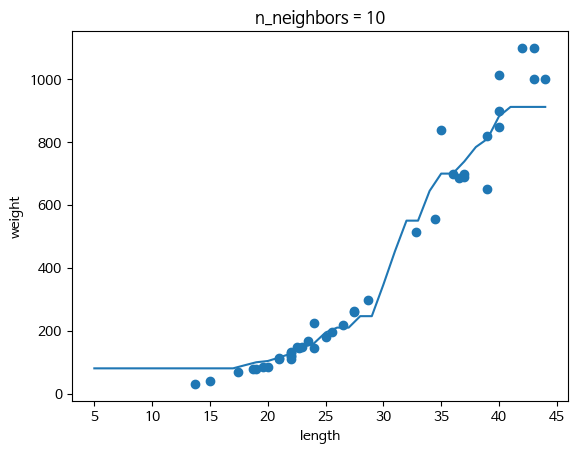

In [21]:
# 앞으로 좋은 결과를 결정해야 할 때 하이퍼 파라미터(5 → 3) 변경은 필수이다.
# 이를 보고서에 남겨서 선택한 결과를 표출해야 한다.
# 그런데 이를 수동으로 바꿔가며 훈련한다면 시간 낭비이다. → 파이썬의 'for문' 등을 많이 사용한다.
# 하이퍼 파라미터 값은 대부분 홀수를 사용한다. (짝수인 경우에는 답이 잘 나오지 않는다.)

knr = KNeighborsRegressor() # K - 최근접 이웃 회귀 객체를 만든다. → 5부터 45까지의 x좌표를 만든다.
x = np.arange(5, 45).reshape(-1, 1)

# n = 1, 3, 4, 10일 때 예측되는 결과를 그래프로 그린다.
for n in [1, 3, 5, 10] :
  # 모델을 훈련시킨다.
  knr.n_neighbors = n
  knr.fit(train_input, train_target)
  # 지정한 범위 x에 대한 예측 구한다.
  prediction = knr.predict(x)
  # 훈련 세트와 예측 결과를 그래프로 그린다.
  plt.scatter(train_input, train_target)
  plt.plot(x, prediction)
  plt.title('n_neighbors = {}'.format(n))
  plt.xlabel('length')
  plt.ylabel('weight')
  plt.show()